# Chemistry reaction rate coefficient optimisation using Jax

Copyright (c) 2025 Wenqing Peng (wenqing.peng@helsinki.fi)  
Licensed under the MIT License. See <https://opensource.org/licenses/MIT> for details.

In [1]:
import jax
import jax.numpy as jnp
import diffrax as dfx
import tqdm
import matplotlib.pyplot as plt

In [ ]:
# NO+O3 -> NO2: 0.266 * 10^2
stoi_reac=jnp.asarray([[1,1,0]]).T  # reaction stoichiometric matrix
stoi_prod=jnp.asarray([[0,0,1]]).T  # product stoichiometric matrix
K = jnp.asarray([0.266e2])          # reaction rate coefficient
ts = jnp.arange(0, 1, 0.1)          # time span
y0 = jnp.asarray([0.2, 0.04, 0])    # initial concentration

In [6]:
def solve(k, stoi_reac, stoi_prod, ts, y0):
    def ode(t, y, args):
        """reaction rate law"""
        k, stoi_reac, stoi_prod = args
      
        rate = k * jnp.prod(y[:, None] ** stoi_reac, axis=0)
        dy_dt  = (stoi_prod - stoi_reac) @ rate
      
        return dy_dt

    sol = dfx.diffeqsolve(
            dfx.ODETerm(ode),
            dfx.Kvaerno5(),
            t0=ts[0],
            t1=ts[-1],
            y0=y0,
            saveat=dfx.SaveAt(ts=ts),
            dt0=None,
            max_steps=8192,
            stepsize_controller=dfx.PIDController(rtol=1e-6, atol=1e-7),
            throw=True,
            args=(k, stoi_reac, stoi_prod),
        )
    return sol.ys

In [7]:
traj_measure = solve(K, stoi_reac, stoi_prod, ts, y0)

In [8]:
traj_measure

Array([[0.2       , 0.04      , 0.        ],
       [0.18404989, 0.02404988, 0.01595012],
       [0.17493452, 0.01493454, 0.02506546],
       [0.169452  , 0.00945201, 0.03054798],
       [0.16605155, 0.00605154, 0.03394846],
       [0.16390243, 0.00390244, 0.03609756],
       [0.16252847, 0.00252848, 0.03747151],
       [0.16164345, 0.00164346, 0.03835654],
       [0.16106944, 0.00106944, 0.03893055],
       [0.16069746, 0.00069752, 0.03930248]], dtype=float32)

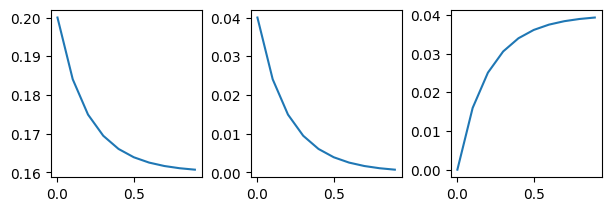

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(6,2), layout='constrained')
for i in range(3):
    axes[i].plot(ts, traj_measure[:,i])
fig.show()

## Automatic differentiation

In [16]:
def mse(prediction, target):
    return jnp.mean((prediction - target) ** 2)

@jax.jit
def loss_fn(k, stoi_reac, stoi_prod, ts, y0, traj_measure):
    traj_pred = solve(k, stoi_reac, stoi_prod, ts, y0)
    return mse(traj_pred, traj_measure)

In [15]:
loss_fn(K, stoi_reac, stoi_prod, ts, y0, traj_measure)

Array(0., dtype=float32)

- `jax.grad` transform a function so that it calculate the gradient w.r.t. (by default the 1st) input argument
- pure jax function is autodiffed by applying the chain rule
- `diffrax` library implements adjoint method to compute gradient of solution w.r.t. input and parameter effeciently

In [17]:
dL_dk_fn = jax.grad(loss_fn)

In [19]:
dL_dk_fn(K, stoi_reac, stoi_prod, ts, y0, traj_measure)

Array([0.], dtype=float32)

## Automatic vectorisation

### Mannual vectorisation

In [ ]:
ks = jnp.logspace(jnp.log10(K*0.1), jnp.log10(K*10), 20)

L = [loss_fn(k, stoi_reac, stoi_prod, ts, y0, traj_measure) for k in ks]
dL_dk = [dL_dk_fn(k, stoi_reac, stoi_prod, ts, y0, traj_measure) for k in ks]

for kk, ll, dd in zip(ks, L, dL_dk):
    print(kk, ll, dd)

[2.66] 0.00053316314 [-0.00012506]
[3.3895717] 0.00045005794 [-0.00010375]
[4.319246] 0.00036400292 [-8.24241e-05]
[5.503907] 0.00027904782 [-6.215045e-05]
[7.0134916] 0.00019987006 [-4.3998156e-05]
[8.937116] 0.0001309214 [-2.8868153e-05]
[11.388345] 7.575082e-05 [-1.7216096e-05]
[14.511882] 3.615915e-05 [-9.017304e-06]
[18.492126] 1.1937936e-05 [-3.8061855e-06]
[23.564056] 1.1969586e-06 [-8.614238e-07]
[30.027086] 1.0657571e-06 [5.68192e-07]
[38.26276] 8.460477e-06 [1.098304e-06]
[48.757286] 2.0564703e-05 [1.1534132e-06]
[62.130188] 3.5007382e-05 [9.916836e-07]
[79.17094] 4.9866972e-05 [7.5729605e-07]
[100.88556] 6.3633786e-05 [5.24609e-07]
[128.5559] 7.5226366e-05 [3.2901386e-07]
[163.81567] 8.400844e-05 [1.8353009e-07]
[208.74614] 8.9851106e-05 [8.827558e-08]
[265.99988] 9.314798e-05 [3.5068016e-08]


### `jax.vmap`
- `jax.vmap` transformed a function so that it takes batched input.
- `in_axes` specifies the which batched dimension is added to which input.

In [ ]:
loss_vfn = jax.jit(
    jax.vmap(
        loss_fn,
        in_axes=(0,None,None,None,None,None),
    )
)
dL_dk_vfn = jax.jit(
    jax.vmap(
        dL_dk_fn,
        in_axes=(0,None,None,None,None,None),
    )
)

In [ ]:
L = loss_vfn(ks, stoi_reac, stoi_prod, ts, y0, traj_measure)
dL_dk = dL_dk_vfn(ks, stoi_reac, stoi_prod, ts, y0, traj_measure)

Text(0.5, 1.0, 'dL_dk')

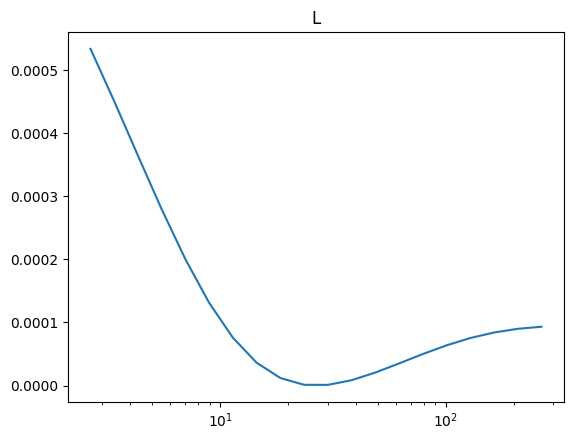

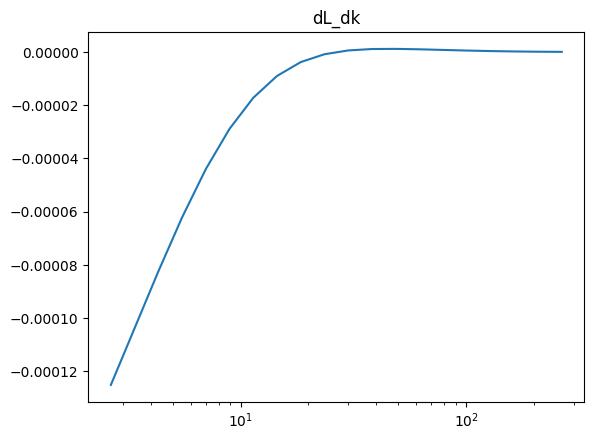

In [ ]:
fig, ax = plt.subplots(1)
ax.plot(ks, L)
ax.set_xscale("log")
ax.set_title("L")

fig, ax = plt.subplots(1)
ax.plot(ks, jnp.squeeze(dL_dk))
ax.set_xscale("log")
ax.set_title("dL_dk")

## Gradient-descent optimisation

In [25]:
k0 = K*0.1
learning_rate = 1e5
epoch = 1000

print(f"ground truth: K={K}")
print(f"before optimisation: k0={k0}")
bar = tqdm.tqdm(range(0, epoch), desc=f"Epochs", initial=0)

for i in bar:
    dL_dk = dL_dk_fn(k0, stoi_reac, stoi_prod, ts, y0, traj_measure)
    k0 = k0 - dL_dk * learning_rate
    bar.set_postfix({'k0': f"{float(jnp.squeeze(k0)):.4e}"})

print(f"after optimisation: k0={k0}")

ground truth: K=[26.6]
before optimisation: k0=[2.66]


Epochs: 100%|██████████| 1000/1000 [03:21<00:00,  4.95it/s, k0=2.6600e+01]

after optimisation: k0=[26.600334]
